# TFM — Sistema detector de fraude en transacciones financieras mediante aprendizaje automático

**Autor:** Álvaro Gómez García  

Este notebook implementa el flujo completo de detección de fraude: descarga y análisis del dataset,
preprocesamiento, tratamiento del desbalanceo (SMOTE, submuestreo y balanceo nativo), entrenamiento
y evaluación de varios modelos supervisados (Regresión Logística, Random Forest, XGBoost y LightGBM),
dos enfoques de **detección de anomalías** (Isolation Forest y un **autoencoder**), medición de
**tiempos de entrenamiento**, **validación cruzada** y una comparación global orientada al *recall*.

> Nota de reproducibilidad: todos los modelos usan `random_state=42` y la misma partición estratificada
> 80/20, de modo que los resultados son reproducibles.

## 0. Descarga del dataset

Se utiliza el conjunto **Credit Card Fraud Detection** (Machine Learning Group – ULB), disponible en Kaggle.

In [1]:
import kagglehub

# Descargar dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Path to dataset files: /Users/alvaro/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [2]:
import os
import pandas as pd

# Comprueba que el archivo está dentro de la carpeta descargada
print(os.listdir(path))

['creditcard.csv']


In [3]:
# Ruta al CSV y carga del dataset
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

# Primeras filas
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Análisis exploratorio inicial (EDA)

El objetivo del EDA es entender el dataset, comprobar el desbalanceo y obtener las primeras métricas
descriptivas para la memoria.

In [4]:
# Dimensiones del dataset
print("Número de filas y columnas:")
print(df.shape)

Número de filas y columnas:
(284807, 31)


In [5]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Comprobación de valores nulos
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
# Distribución de clases  (0 = legítima, 1 = fraudulenta)
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
# Porcentaje de fraude
fraud_percentage = (df['Class'].value_counts()[1] / len(df)) * 100
print(f"Porcentaje de transacciones fraudulentas: {fraud_percentage:.4f}%")

Porcentaje de transacciones fraudulentas: 0.1727%


### 1.1. Muestras del dataset

Para dar una idea concreta de la estructura de los datos, se muestran algunas transacciones legítimas
y fraudulentas, así como un resumen estadístico de las variables no anonimizadas (`Time` y `Amount`).

In [9]:
# Muestra de transacciones LEGÍTIMAS (Class = 0)
print("Ejemplos de transacciones legítimas:")
display(df[df['Class'] == 0].head(3))

# Muestra de transacciones FRAUDULENTAS (Class = 1)
print("Ejemplos de transacciones fraudulentas:")
display(df[df['Class'] == 1].head(3))

Ejemplos de transacciones legítimas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


Ejemplos de transacciones fraudulentas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1


In [10]:
# Resumen estadístico de las variables no anonimizadas
df[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


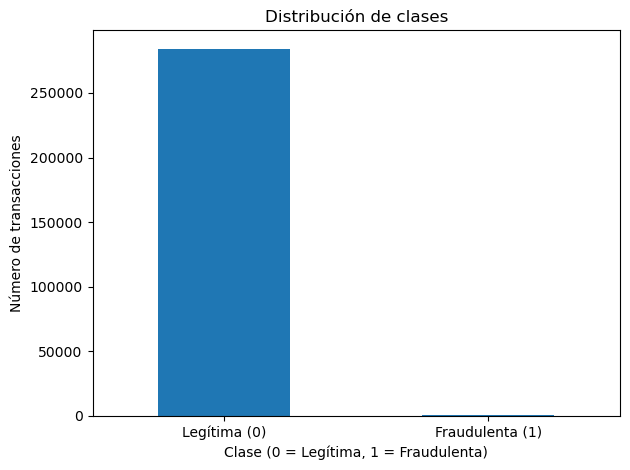

In [11]:
import matplotlib.pyplot as plt

# Distribución de clases (representación gráfica)
df['Class'].value_counts().plot(kind='bar')
plt.title('Distribución de clases')
plt.xlabel('Clase (0 = Legítima, 1 = Fraudulenta)')
plt.ylabel('Número de transacciones')
plt.xticks([0, 1], ['Legítima (0)', 'Fraudulenta (1)'], rotation=0)
plt.tight_layout()
plt.show()

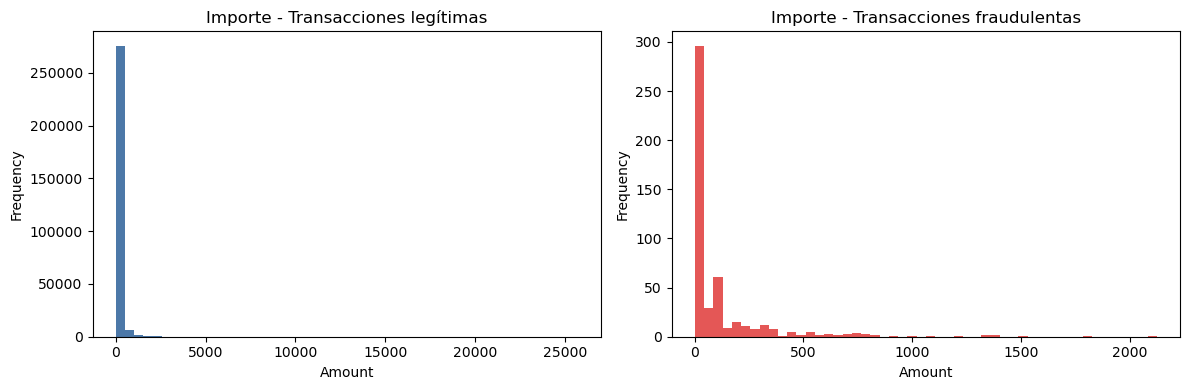

In [12]:
# Comparación del importe (Amount) entre transacciones legítimas y fraudulentas
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[df['Class'] == 0]['Amount'].plot(kind='hist', bins=50, ax=ax[0], color='#4C78A8')
ax[0].set_title('Importe - Transacciones legítimas')
ax[0].set_xlabel('Amount')
df[df['Class'] == 1]['Amount'].plot(kind='hist', bins=50, ax=ax[1], color='#E45756')
ax[1].set_title('Importe - Transacciones fraudulentas')
ax[1].set_xlabel('Amount')
plt.tight_layout()
plt.show()

## 2. Preprocesamiento y partición de los datos

Se separan las variables predictoras (`X`) de la variable objetivo (`y`) y se divide el conjunto en
**entrenamiento (80%)** y **prueba (20%)** mediante una división **estratificada**, que mantiene la
proporción original de fraude en ambos subconjuntos.

In [13]:
# Variables predictoras (características de cada transacción)
X = df.drop('Class', axis=1)
# Variable objetivo (0 = legítima, 1 = fraudulenta)
y = df['Class']

In [14]:
from sklearn.model_selection import train_test_split

# División estratificada 80/20 (mantiene el % de fraude en train y test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Fraude en train:", int(y_train.sum()), " | Fraude en test:", int(y_test.sum()))

Train: (227845, 30)
Test : (56962, 30)
Fraude en train: 394  | Fraude en test: 98


### 2.1. Sobre el conjunto de validación

El **conjunto de prueba (test)** se reserva y **no se utiliza en ningún momento** durante el
entrenamiento ni la selección de modelos: solo sirve para la evaluación final.

Para la **validación** (comparar modelos y estimar su capacidad de generalización sin tocar el test)
se emplea **validación cruzada estratificada de 5 particiones (Stratified 5-Fold)** aplicada
**sobre el conjunto de entrenamiento**. De este modo, cada modelo se valida sobre particiones internas
del train antes de la evaluación definitiva sobre el test. Esta validación cruzada se realiza en la
Sección 8.

## 3. Tratamiento del desbalanceo

El dataset presenta un fuerte desbalanceo (las transacciones fraudulentas son ~0,17% del total).
En este trabajo se comparan **tres estrategias** para tratarlo:

1. **SMOTE** (sobremuestreo sintético de la clase minoritaria).
2. **Submuestreo aleatorio** de la clase mayoritaria (*Random Undersampling*), como alternativa a SMOTE.
3. **Balanceo nativo** integrado en los propios algoritmos (`class_weight='balanced'` en Regresión
   Logística, Random Forest y LightGBM, y `scale_pos_weight` en XGBoost), que **no genera datos
   sintéticos** sino que penaliza más los errores sobre la clase minoritaria.

**Importante:** cualquier técnica de remuestreo se aplica **solo sobre el conjunto de entrenamiento**,
nunca sobre el test, para no introducir sesgos en la evaluación.

In [15]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# --- Estrategia 1: SMOTE (sobremuestreo sintético) ---
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# --- Estrategia 2: Submuestreo aleatorio de la clase mayoritaria ---
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Distribución original (train):")
print(y_train.value_counts().to_dict())
print("\nTras SMOTE:", y_train_smote.value_counts().to_dict())
print("Tras submuestreo:", y_train_rus.value_counts().to_dict())

Distribución original (train):
{0: 227451, 1: 394}

Tras SMOTE: {0: 227451, 1: 227451}
Tras submuestreo: {0: 394, 1: 394}


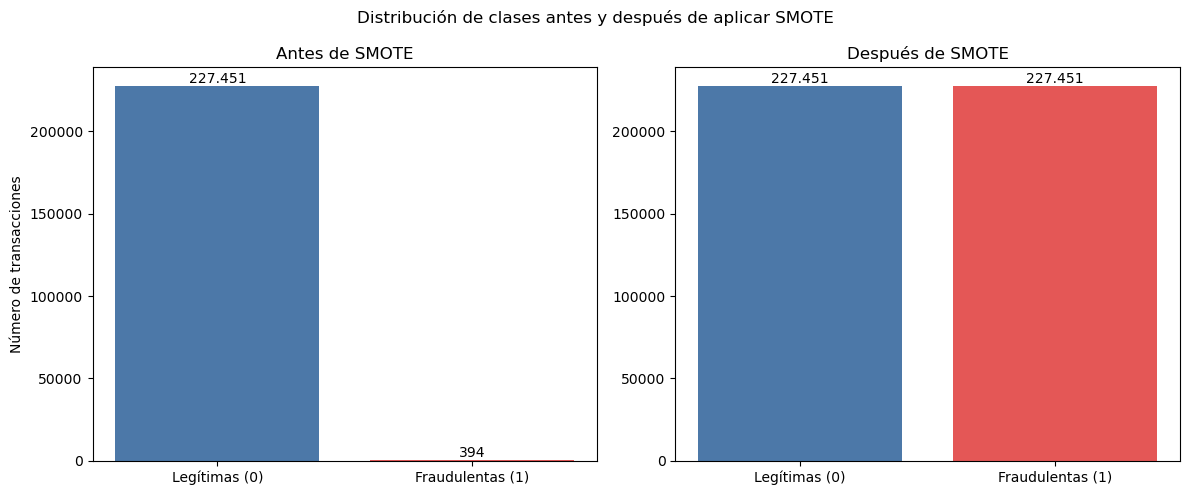

In [16]:
# Visualización: distribución de clases antes y después de aplicar SMOTE
import matplotlib.pyplot as plt

antes = y_train.value_counts().sort_index().values
despues = y_train_smote.value_counts().sort_index().values

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].bar(["Legítimas (0)", "Fraudulentas (1)"], antes, color=['#4C78A8', '#E45756'])
ax[0].set_title("Antes de SMOTE")
ax[0].set_ylabel("Número de transacciones")
for i, v in enumerate(antes):
    ax[0].text(i, v, f"{v:,}".replace(",", "."), ha="center", va="bottom")

ax[1].bar(["Legítimas (0)", "Fraudulentas (1)"], despues, color=['#4C78A8', '#E45756'])
ax[1].set_title("Después de SMOTE")
for i, v in enumerate(despues):
    ax[1].text(i, v, f"{v:,}".replace(",", "."), ha="center", va="bottom")

plt.suptitle("Distribución de clases antes y después de aplicar SMOTE")
plt.tight_layout()
plt.show()

## 4. Utilidades de evaluación

Se definen funciones auxiliares para: (a) medir el **tiempo de entrenamiento** de cada modelo,
(b) representar las **matrices de confusión con etiquetas legibles** ("Legítima" / "Fraudulenta")
y (c) recopilar las métricas (precisión, recall y F1 sobre la clase fraude) en una tabla común.

In [17]:
import time
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_fscore_support)

# Etiquetas legibles para las matrices de confusión
LABELS = ["Legítima", "Fraudulenta"]

# Almacén global de resultados (se irá rellenando con cada modelo)
resultados = []      # métricas
tiempos = {}         # tiempos de entrenamiento (s)

def entrenar_con_tiempo(modelo, X_tr, y_tr, nombre):
    """Entrena un modelo midiendo el tiempo de entrenamiento."""
    inicio = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    dur = time.perf_counter() - inicio
    tiempos[nombre] = dur
    print(f"[{nombre}] tiempo de entrenamiento: {dur:.2f} s")
    return modelo

def evaluar(nombre, y_true, y_pred, cmap="Blues", balanceo=""):
    """Imprime el informe, guarda métricas y dibuja la matriz de confusión etiquetada."""
    print(classification_report(y_true, y_pred, target_names=LABELS, digits=3))
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1], average=None, zero_division=0)
    resultados.append({
        "Modelo": nombre, "Balanceo": balanceo,
        "Precision": round(float(p[0]), 3),
        "Recall": round(float(r[0]), 3),
        "F1-Score": round(float(f[0]), 3),
        "Tiempo (s)": round(tiempos.get(nombre, float("nan")), 2),
    })
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(cmap=cmap, values_format="d")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.tight_layout()
    fname = "fig_" + nombre.replace(" ", "_").replace("(", "").replace(")", "") + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    return cm

## 5. Modelos supervisados con SMOTE

Se entrenan cuatro modelos de clasificación sobre el conjunto **equilibrado con SMOTE** y se evalúan
sobre el conjunto de prueba original. Para cada modelo se indican de forma **explícita los
hiperparámetros** utilizados.

### 5.1. Regresión Logística

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# La Regresión Logística es sensible a la escala -> se estandarizan las variables
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Hiperparámetros explícitos
log_model = LogisticRegression(
    max_iter=2000,     # iteraciones suficientes para converger
    C=1.0,             # inverso de la regularización (valor por defecto)
    solver="lbfgs",    # optimizador
    random_state=42
)
log_model = entrenar_con_tiempo(log_model, X_train_smote_scaled, y_train_smote, "Regresión Logística")

[Regresión Logística] tiempo de entrenamiento: 1.21 s


              precision    recall  f1-score   support

    Legítima      1.000     0.990     0.995     56864
 Fraudulenta      0.134     0.898     0.233        98

    accuracy                          0.990     56962
   macro avg      0.567     0.944     0.614     56962
weighted avg      0.998     0.990     0.994     56962



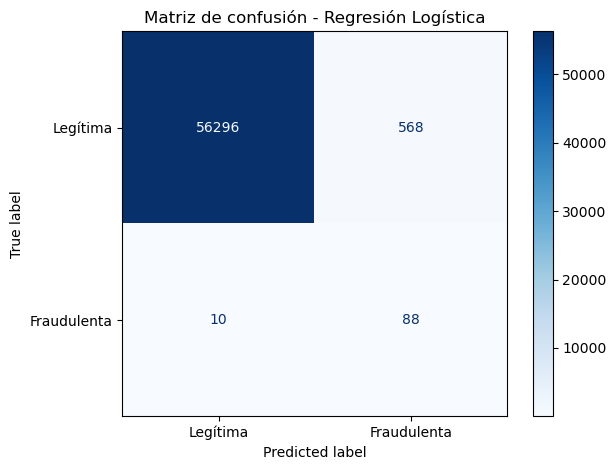

array([[56296,   568],
       [   10,    88]])

In [19]:
y_pred_lr = log_model.predict(X_test_scaled)
evaluar("Regresión Logística", y_test, y_pred_lr, cmap="Blues", balanceo="SMOTE")

### 5.2. Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,   # número de árboles
    max_depth=None,     # sin límite de profundidad
    n_jobs=-1,          # usa todos los núcleos
    random_state=42
)
rf_model = entrenar_con_tiempo(rf_model, X_train_smote, y_train_smote, "Random Forest")

[Random Forest] tiempo de entrenamiento: 38.75 s


              precision    recall  f1-score   support

    Legítima      1.000     1.000     1.000     56864
 Fraudulenta      0.827     0.827     0.827        98

    accuracy                          0.999     56962
   macro avg      0.913     0.913     0.913     56962
weighted avg      0.999     0.999     0.999     56962



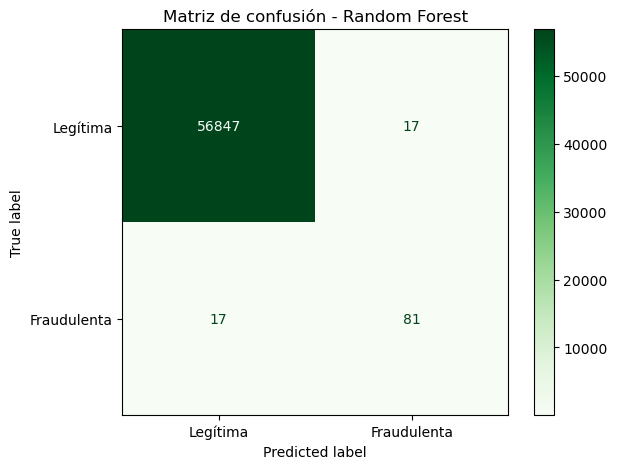

array([[56847,    17],
       [   17,    81]])

In [21]:
y_pred_rf = rf_model.predict(X_test)
evaluar("Random Forest", y_test, y_pred_rf, cmap="Greens", balanceo="SMOTE")

### 5.3. XGBoost

In [22]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    subsample=1.0,
    eval_metric="logloss",
    random_state=42
)
xgb_model = entrenar_con_tiempo(xgb_model, X_train_smote, y_train_smote, "XGBoost")

[XGBoost] tiempo de entrenamiento: 0.97 s


              precision    recall  f1-score   support

    Legítima      1.000     1.000     1.000     56864
 Fraudulenta      0.790     0.847     0.818        98

    accuracy                          0.999     56962
   macro avg      0.895     0.923     0.909     56962
weighted avg      0.999     0.999     0.999     56962



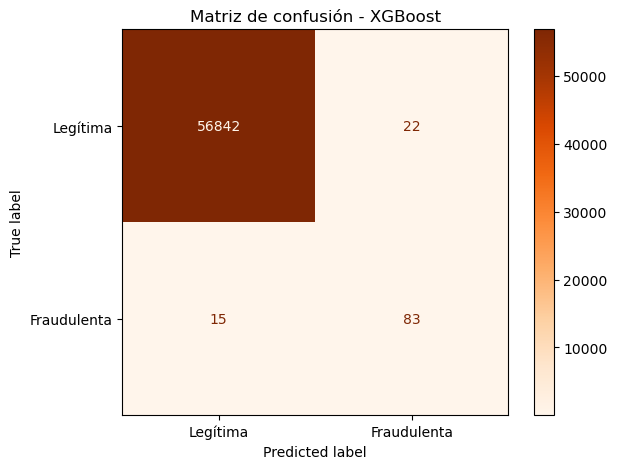

array([[56842,    22],
       [   15,    83]])

In [23]:
y_pred_xgb = xgb_model.predict(X_test)
evaluar("XGBoost", y_test, y_pred_xgb, cmap="Oranges", balanceo="SMOTE")

### 5.4. LightGBM

In [24]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    num_leaves=31,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgbm_model = entrenar_con_tiempo(lgbm_model, X_train_smote, y_train_smote, "LightGBM")

[LightGBM] tiempo de entrenamiento: 1.05 s


              precision    recall  f1-score   support

    Legítima      1.000     0.999     0.999     56864
 Fraudulenta      0.598     0.806     0.687        98

    accuracy                          0.999     56962
   macro avg      0.799     0.903     0.843     56962
weighted avg      0.999     0.999     0.999     56962



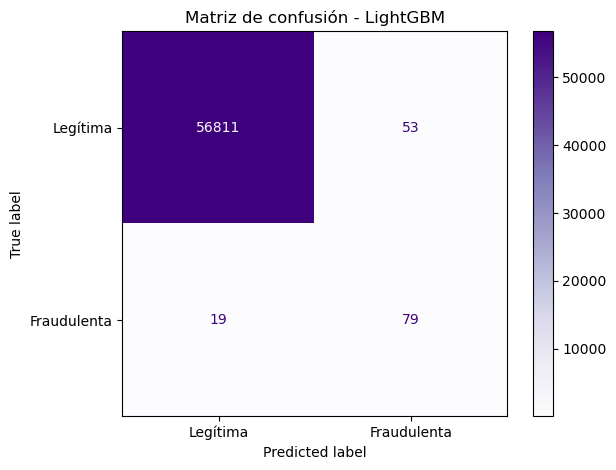

array([[56811,    53],
       [   19,    79]])

In [25]:
y_pred_lgbm = lgbm_model.predict(X_test)
evaluar("LightGBM", y_test, y_pred_lgbm, cmap="Purples", balanceo="SMOTE")

## 6. Enfoques de detección de anomalías

Además de los modelos supervisados, se evalúan dos enfoques **no supervisados / semisupervisados**
que abordan el fraude como la detección de un comportamiento **anómalo**. Este tipo de enfoque es
especialmente relevante cuando las transacciones fraudulentas son escasas o presentan patrones
difíciles de capturar con clasificación supervisada.

### 6.1. Isolation Forest

Isolation Forest aísla observaciones mediante particiones aleatorias: las anomalías, al ser escasas y
diferentes, se aíslan con menos particiones. Se entrena de forma **no supervisada** (sin usar las
etiquetas) fijando el parámetro `contamination` a la proporción real de fraude.

In [26]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=float(y_train.mean()),  # proporción esperada de anomalías
    random_state=42,
    n_jobs=-1
)
# Se entrena SIN etiquetas (no supervisado)
iso_model = entrenar_con_tiempo(iso_model, X_train, None, "Isolation Forest")

[Isolation Forest] tiempo de entrenamiento: 1.11 s


              precision    recall  f1-score   support

    Legítima      0.999     0.999     0.999     56864
 Fraudulenta      0.280     0.306     0.293        98

    accuracy                          0.997     56962
   macro avg      0.640     0.652     0.646     56962
weighted avg      0.998     0.997     0.998     56962



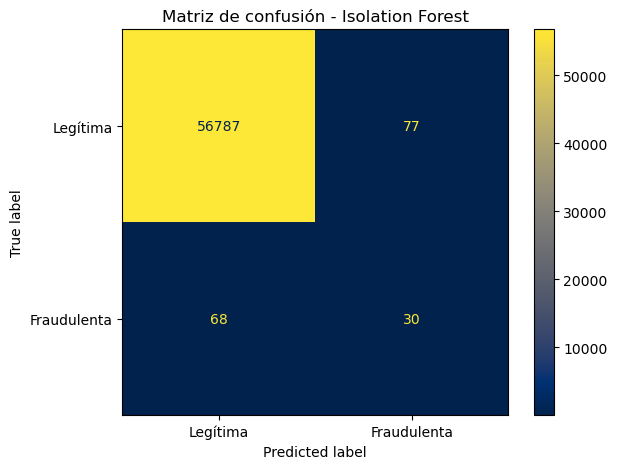

array([[56787,    77],
       [   68,    30]])

In [27]:
# Isolation Forest devuelve -1 para anomalías y 1 para normales -> se mapea a 1=fraude, 0=legítima
pred_iso_raw = iso_model.predict(X_test)
y_pred_iso = np.where(pred_iso_raw == -1, 1, 0)
evaluar("Isolation Forest", y_test, y_pred_iso, cmap="cividis", balanceo="No supervisado")

### 6.2. Autoencoder

Un **autoencoder** es una red neuronal que aprende a **reconstruir** su entrada a través de una capa
intermedia de menor dimensión (cuello de botella). Se entrena **únicamente con transacciones
legítimas**, de modo que aprende su patrón normal; cuando se le presenta una transacción fraudulenta,
el **error de reconstrucción** es mayor. Superado un umbral (percentil del error en entrenamiento),
la transacción se marca como fraude.

Se implementa mediante un perceptrón multicapa simétrico (`MLPRegressor` de scikit-learn), evitando
dependencias de frameworks externos de *deep learning*.

In [28]:
from sklearn.neural_network import MLPRegressor

# Se entrena solo con transacciones legítimas del train, estandarizadas
scaler_ae = StandardScaler().fit(X_train[y_train == 0])
X_train_norm = scaler_ae.transform(X_train[y_train == 0])
X_test_ae = scaler_ae.transform(X_test)

autoencoder = MLPRegressor(
    hidden_layer_sizes=(20, 14, 7, 14, 20),  # arquitectura simétrica con cuello de botella de 7
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=60,
    random_state=42
)
autoencoder = entrenar_con_tiempo(autoencoder, X_train_norm, X_train_norm, "Autoencoder")

[Autoencoder] tiempo de entrenamiento: 16.91 s


/Users/alvaro/Desktop/Aplicaciones/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


Umbral de error de reconstrucción: 1.9869
              precision    recall  f1-score   support

    Legítima      1.000     0.990     0.995     56864
 Fraudulenta      0.118     0.816     0.206        98

    accuracy                          0.989     56962
   macro avg      0.559     0.903     0.601     56962
weighted avg      0.998     0.989     0.993     56962



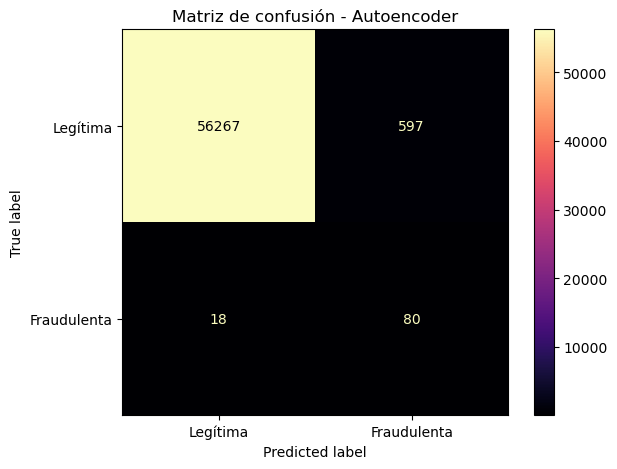

array([[56267,   597],
       [   18,    80]])

In [29]:
# Error de reconstrucción (MSE por muestra)
rec_train = np.mean((X_train_norm - autoencoder.predict(X_train_norm))**2, axis=1)
rec_test = np.mean((X_test_ae - autoencoder.predict(X_test_ae))**2, axis=1)

# Umbral: percentil 99 del error en entrenamiento (equivale a ~1% de anomalías esperadas)
umbral = np.percentile(rec_train, 99)
print(f"Umbral de error de reconstrucción: {umbral:.4f}")

y_pred_ae = (rec_test > umbral).astype(int)
evaluar("Autoencoder", y_test, y_pred_ae, cmap="magma", balanceo="Semisupervisado")

## 7. Comparación de estrategias de balanceo

Para responder a la pregunta de si SMOTE es la mejor opción, se comparan las **tres estrategias de
balanceo** sobre dos modelos representativos (Random Forest y XGBoost/LightGBM), incluyendo el
**balanceo nativo** de cada algoritmo, que no genera datos sintéticos.

[Random Forest (submuestreo)] tiempo de entrenamiento: 0.09 s
              precision    recall  f1-score   support

    Legítima      1.000     0.964     0.982     56864
 Fraudulenta      0.042     0.908     0.080        98

    accuracy                          0.964     56962
   macro avg      0.521     0.936     0.531     56962
weighted avg      0.998     0.964     0.980     56962



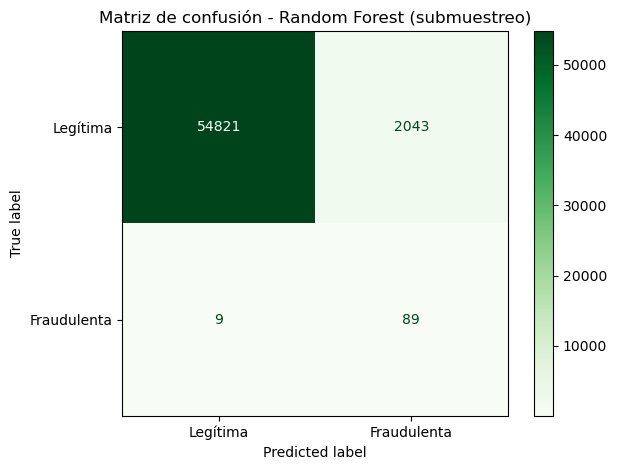

array([[54821,  2043],
       [    9,    89]])

In [30]:
# --- Random Forest: SMOTE vs submuestreo vs class_weight nativo ---
# (a) submuestreo aleatorio
rf_rus = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_rus = entrenar_con_tiempo(rf_rus, X_train_rus, y_train_rus, "Random Forest (submuestreo)")
evaluar("Random Forest (submuestreo)", y_test, rf_rus.predict(X_test), cmap="Greens", balanceo="Submuestreo")

[Random Forest (class_weight)] tiempo de entrenamiento: 10.46 s
              precision    recall  f1-score   support

    Legítima      1.000     1.000     1.000     56864
 Fraudulenta      0.961     0.745     0.839        98

    accuracy                          1.000     56962
   macro avg      0.980     0.872     0.919     56962
weighted avg      0.999     1.000     0.999     56962



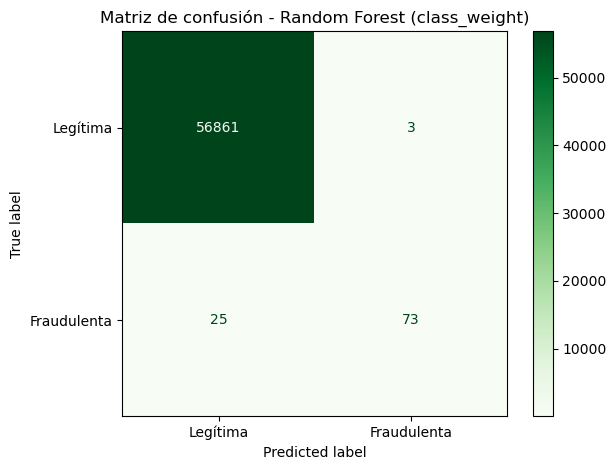

array([[56861,     3],
       [   25,    73]])

In [31]:
# (b) class_weight nativo (sin remuestrear: entrena sobre el train original desbalanceado)
rf_cw = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42,
                               class_weight="balanced")
rf_cw = entrenar_con_tiempo(rf_cw, X_train, y_train, "Random Forest (class_weight)")
evaluar("Random Forest (class_weight)", y_test, rf_cw.predict(X_test), cmap="Greens", balanceo="Nativo")

scale_pos_weight = 577.3
[XGBoost (scale_pos_weight)] tiempo de entrenamiento: 0.53 s
              precision    recall  f1-score   support

    Legítima      1.000     1.000     1.000     56864
 Fraudulenta      0.882     0.837     0.859        98

    accuracy                          1.000     56962
   macro avg      0.941     0.918     0.929     56962
weighted avg      1.000     1.000     1.000     56962



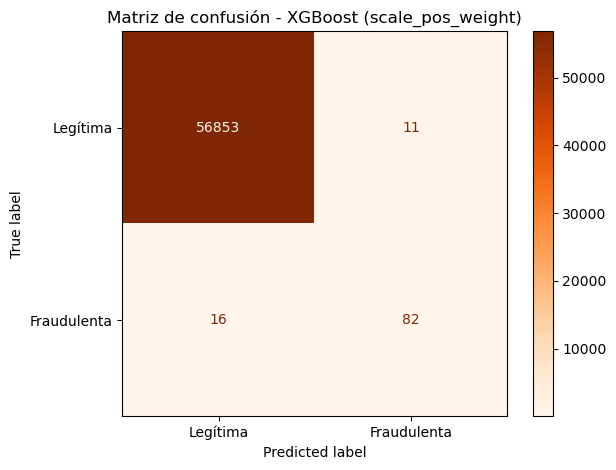

array([[56853,    11],
       [   16,    82]])

In [32]:
# --- XGBoost con balanceo NATIVO mediante scale_pos_weight (sin SMOTE) ---
# scale_pos_weight = nº negativos / nº positivos en el train
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {spw:.1f}")

xgb_native = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.3,
    scale_pos_weight=spw, eval_metric="logloss", random_state=42
)
xgb_native = entrenar_con_tiempo(xgb_native, X_train, y_train, "XGBoost (scale_pos_weight)")
evaluar("XGBoost (scale_pos_weight)", y_test, xgb_native.predict(X_test), cmap="Oranges", balanceo="Nativo")

[LightGBM (class_weight)] tiempo de entrenamiento: 0.63 s
              precision    recall  f1-score   support

    Legítima      1.000     1.000     1.000     56864
 Fraudulenta      0.817     0.867     0.842        98

    accuracy                          0.999     56962
   macro avg      0.909     0.934     0.921     56962
weighted avg      0.999     0.999     0.999     56962



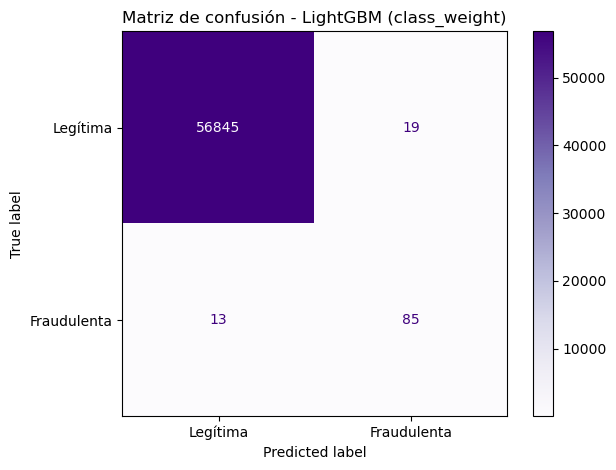

array([[56845,    19],
       [   13,    85]])

In [33]:
# --- LightGBM con balanceo NATIVO mediante class_weight='balanced' (sin SMOTE) ---
lgbm_native = LGBMClassifier(
    n_estimators=100, num_leaves=31, learning_rate=0.1,
    class_weight="balanced", random_state=42, verbose=-1
)
lgbm_native = entrenar_con_tiempo(lgbm_native, X_train, y_train, "LightGBM (class_weight)")
evaluar("LightGBM (class_weight)", y_test, lgbm_native.predict(X_test), cmap="Purples", balanceo="Nativo")

## 8. Validación cruzada estratificada

Para validar la robustez de los modelos supervisados sin usar el conjunto de prueba, se aplica
**validación cruzada estratificada de 5 particiones** sobre el conjunto de **entrenamiento**. Para
evitar fugas de información (*data leakage*), el remuestreo con SMOTE se realiza **dentro de cada
partición** mediante un `Pipeline` de imbalanced-learn. Se reporta el **recall** medio, por ser la
métrica prioritaria en detección de fraude.

In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = {
    "Regresión Logística": ImbPipeline([("smote", SMOTE(random_state=42)),
                                          ("scaler", StandardScaler()),
                                          ("clf", LogisticRegression(max_iter=2000, random_state=42))]),
    "Random Forest": ImbPipeline([("smote", SMOTE(random_state=42)),
                                   ("clf", RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42))]),
    "XGBoost": ImbPipeline([("smote", SMOTE(random_state=42)),
                             ("clf", XGBClassifier(n_estimators=100, eval_metric="logloss", random_state=42))]),
    "LightGBM": ImbPipeline([("smote", SMOTE(random_state=42)),
                              ("clf", LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))]),
}

print("Recall medio en validación cruzada (5-fold estratificado):\n")
for nombre, pipe in modelos_cv.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="recall", n_jobs=-1)
    print(f"{nombre:22s} recall = {scores.mean():.3f} ± {scores.std():.3f}   folds={np.round(scores,3)}")

Recall medio en validación cruzada (5-fold estratificado):

Regresión Logística    recall = 0.891 ± 0.038   folds=[0.936 0.848 0.861 0.937 0.873]
Random Forest          recall = 0.812 ± 0.042   folds=[0.859 0.772 0.759 0.861 0.81 ]
XGBoost                recall = 0.833 ± 0.032   folds=[0.859 0.785 0.81  0.873 0.835]
LightGBM               recall = 0.825 ± 0.020   folds=[0.846 0.797 0.823 0.848 0.81 ]


## 9. Comparación global de resultados

Se resume el rendimiento de **todos** los modelos y estrategias en una única tabla, incluyendo el
**tiempo de entrenamiento**. La discusión se orienta al **recall** (capacidad de detectar fraude,
es decir, minimizar falsos negativos), métrica prioritaria en este dominio, sin descuidar la precisión
(número de falsas alarmas).

In [35]:
# Tabla comparativa unificada de todos los modelos evaluados
tabla = pd.DataFrame(resultados)
tabla = tabla[["Modelo", "Balanceo", "Precision", "Recall", "F1-Score", "Tiempo (s)"]]
tabla

,Modelo,Balanceo,Precision,Recall,F1-Score,Tiempo (s)
0,Regresión Logística,SMOTE,0.134,0.898,0.233,1.21
1,Random Forest,SMOTE,0.827,0.827,0.827,38.75
2,XGBoost,SMOTE,0.790,0.847,0.818,0.97
3,LightGBM,SMOTE,0.598,0.806,0.687,1.05
4,Isolation Forest,No supervisado,0.280,0.306,0.293,1.11
5,Autoencoder,Semisupervisado,0.118,0.816,0.206,16.91
6,Random Forest (submuestreo),Submuestreo,0.042,0.908,0.080,0.09
7,Random Forest (class_weight),Nativo,0.961,0.745,0.839,10.46
8,XGBoost (scale_pos_weight),Nativo,0.882,0.837,0.859,0.53
9,LightGBM (class_weight),Nativo,0.817,0.867,0.842,0.63


In [36]:
# Ordenar por recall (métrica prioritaria en detección de fraude)
tabla_recall = tabla.sort_values("Recall", ascending=False).reset_index(drop=True)
print("Modelos ordenados por RECALL (prioridad en detección de fraude):")
tabla_recall

Modelos ordenados por RECALL (prioridad en detección de fraude):


,Modelo,Balanceo,Precision,Recall,F1-Score,Tiempo (s)
0,Random Forest (submuestreo),Submuestreo,0.042,0.908,0.080,0.09
1,Regresión Logística,SMOTE,0.134,0.898,0.233,1.21
2,LightGBM (class_weight),Nativo,0.817,0.867,0.842,0.63
3,XGBoost,SMOTE,0.790,0.847,0.818,0.97
4,XGBoost (scale_pos_weight),Nativo,0.882,0.837,0.859,0.53
5,Random Forest,SMOTE,0.827,0.827,0.827,38.75
6,Autoencoder,Semisupervisado,0.118,0.816,0.206,16.91
7,LightGBM,SMOTE,0.598,0.806,0.687,1.05
8,Random Forest (class_weight),Nativo,0.961,0.745,0.839,10.46
9,Isolation Forest,No supervisado,0.280,0.306,0.293,1.11


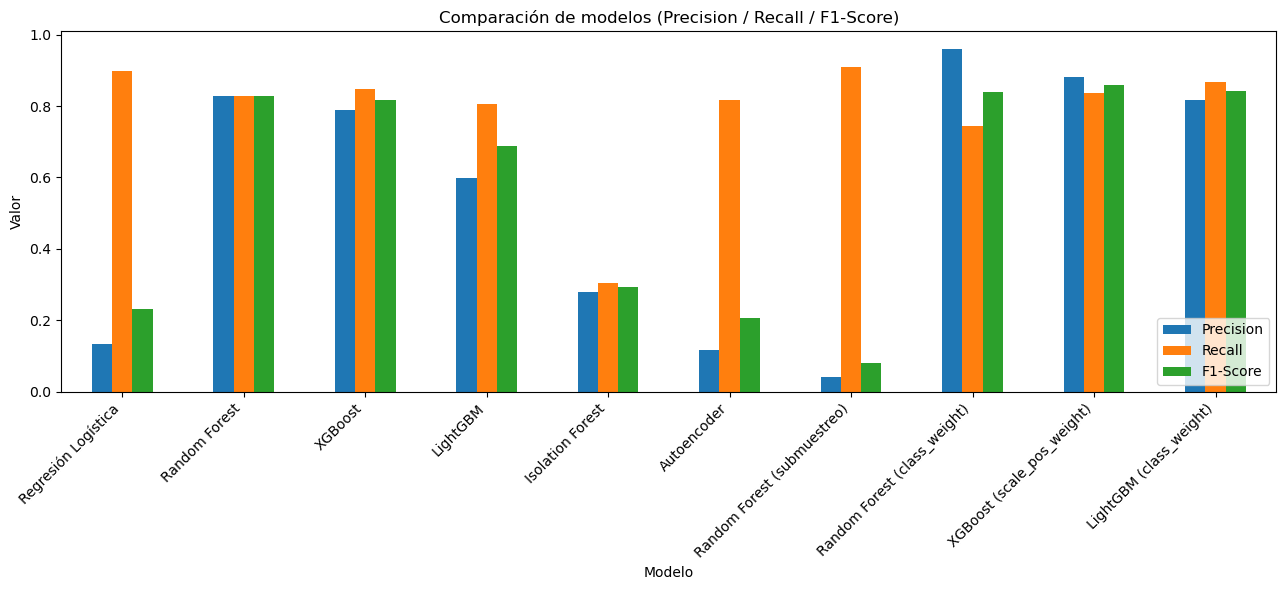

In [37]:
# Gráfico comparativo de métricas por modelo
import matplotlib.pyplot as plt

tabla_plot = tabla.set_index("Modelo")[["Precision", "Recall", "F1-Score"]]
ax = tabla_plot.plot(kind="bar", figsize=(13, 6))
plt.title("Comparación de modelos (Precision / Recall / F1-Score)")
plt.ylabel("Valor")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

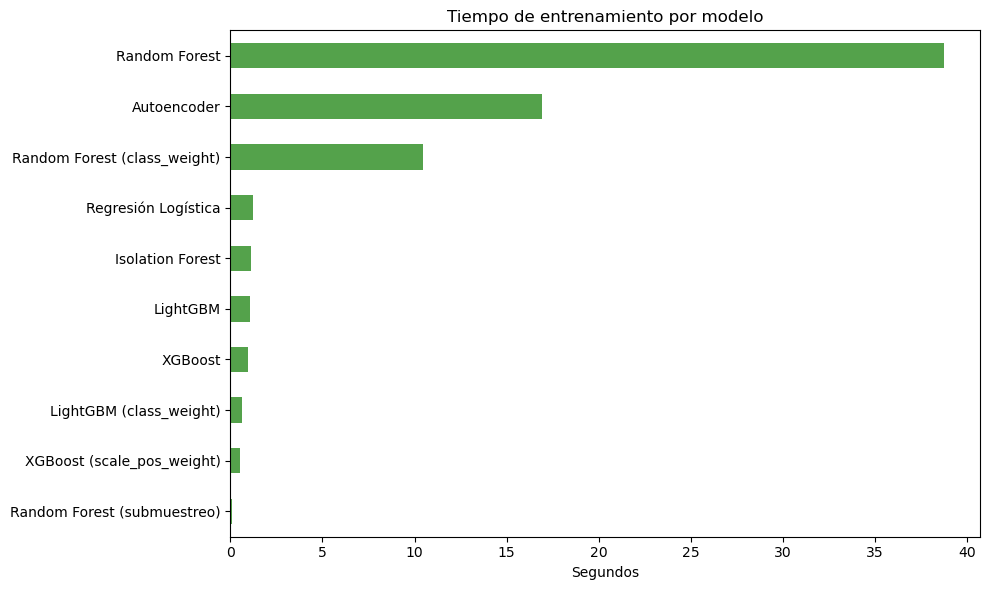

In [38]:
# Gráfico comparativo de tiempos de entrenamiento
tiempos_ser = pd.Series(tiempos).sort_values()
ax = tiempos_ser.plot(kind="barh", figsize=(10, 6), color="#54A24B")
plt.title("Tiempo de entrenamiento por modelo")
plt.xlabel("Segundos")
plt.tight_layout()
plt.show()

In [39]:
# Guardar la tabla de resultados a CSV (para incorporarla a la memoria)
tabla.to_csv("resultados_modelos.csv", index=False)
print("Guardado: resultados_modelos.csv")
tabla

Guardado: resultados_modelos.csv


,Modelo,Balanceo,Precision,Recall,F1-Score,Tiempo (s)
0,Regresión Logística,SMOTE,0.134,0.898,0.233,1.21
1,Random Forest,SMOTE,0.827,0.827,0.827,38.75
2,XGBoost,SMOTE,0.790,0.847,0.818,0.97
3,LightGBM,SMOTE,0.598,0.806,0.687,1.05
4,Isolation Forest,No supervisado,0.280,0.306,0.293,1.11
5,Autoencoder,Semisupervisado,0.118,0.816,0.206,16.91
6,Random Forest (submuestreo),Submuestreo,0.042,0.908,0.080,0.09
7,Random Forest (class_weight),Nativo,0.961,0.745,0.839,10.46
8,XGBoost (scale_pos_weight),Nativo,0.882,0.837,0.859,0.53
9,LightGBM (class_weight),Nativo,0.817,0.867,0.842,0.63


## 10. Conclusión del análisis

La tabla y los gráficos anteriores permiten comparar los modelos en tres dimensiones: **capacidad de
detección (recall)**, **precisión** y **coste computacional (tiempo de entrenamiento)**.

En detección de fraude, un **falso negativo** (un fraude no detectado) suele ser más costoso que un
**falso positivo** (una alerta revisada de más), por lo que el **recall** es la métrica prioritaria,
siempre que la precisión se mantenga en niveles operativamente aceptables. La discusión final de estos
resultados se desarrolla en la memoria.